In [290]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pd.set_option('display.max_columns', None)

In [291]:
df = pd.read_csv("seattle_filtered.csv")
df["neighbourhood_group_cleansed"].unique()

<StringArray>
['Other neighborhoods',             'Ballard',             'Cascade',
      'Rainier Valley',            'Magnolia',        'West Seattle',
          'Queen Anne',            'Downtown',        'Capitol Hill',
         'Beacon Hill',           'Lake City',        'Central Area',
 'University District',            'Delridge',           'Northgate',
         'Seward Park',            'Interbay']
Length: 17, dtype: str

In [292]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6072 entries, 0 to 6071
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            6072 non-null   int64  
 1   listing_url                                   6072 non-null   str    
 2   scrape_id                                     6072 non-null   int64  
 3   last_scraped                                  6072 non-null   str    
 4   source                                        6072 non-null   str    
 5   name                                          6072 non-null   str    
 6   description                                   6072 non-null   str    
 7   neighborhood_overview                         6072 non-null   str    
 8   picture_url                                   6072 non-null   str    
 9   host_id                                       6072 non-null   int64  
 10 

In [293]:
## host_response_time
mapping_host_response_time = {
    'within an hour': 1,
    'within a few hours': 2,
    'within a day': 3,
    'a few days or more': 4
}

df['host_response_time'] = df['host_response_time'].map(mapping_host_response_time)

In [294]:
# relative price
group = ["bedrooms", "bathrooms", "neighbourhood_group_cleansed", "room_type"]
df["avg_price_group"] = df.groupby(group)["price"].transform("mean")
df["relative_price"] = df["price"] / df["avg_price_group"]

In [295]:
## minimum nights -> short-term listing vs. long-term listing
threshold = 7

df['is_long_term'] = (df["minimum_nights"] > threshold).astype(int)

In [296]:
## recent_review_proportion : number_of_reviews_ltm / number_of_reviews

df["recent_review_proportion"] = df["number_of_reviews_ltm"] / df["number_of_reviews"]

df

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,avg_price_group,relative_price,is_long_term,recent_review_proportion
0,6606,https://www.airbnb.com/rooms/6606,20250925032813,2025-09-25,city scrape,"Fab, private seattle urban cottage!","This tiny cottage is only 15x10, but it has ev...","A peaceful yet highly accessible neighborhood,...",https://a0.muscache.com/pictures/45742/21116d7...,14942,https://www.airbnb.com/users/show/14942,Joyce,2009-04-26,"Seattle, WA",I am a therapist/innkeeper.I know my city well...,2.0,100%,82%,t,https://a0.muscache.com/im/users/14942/profile...,https://a0.muscache.com/im/users/14942/profile...,Wallingford,5.0,5.0,"['email', 'phone']",t,t,Neighborhood highlights,Wallingford,Other neighborhoods,47.654440,-122.336290,Entire guesthouse,Entire home/apt,1,1.0,1 bath,1.0,1.0,"[""Free parking on premises"", ""Dedicated worksp...",99.0,30,1125,30.0,30.0,1125.0,1125.0,30.0,1125.0,0.0,t,27,57,87,177,2025-09-25,161,0,0,95,1,0,0.0,2009-07-17,2024-09-07,4.60,4.67,4.67,4.83,4.77,4.88,4.57,str-opli-19-002622,f,3,3,0,0,0.82,124.229050,0.796915,1,0.000000
1,9419,https://www.airbnb.com/rooms/9419,20250925032813,2025-09-25,city scrape,Glorious sun room w/ memory foambed,This beautiful double room features sun filled...,"Lots of restaurants (see our guide book) bars,...",https://a0.muscache.com/pictures/56645186/e5fb...,30559,https://www.airbnb.com/users/show/30559,Angielena,2009-08-09,"Seattle, WA",I am a visual artist who is the director ...,1.0,100%,97%,t,https://a0.muscache.com/im/pictures/user/User-...,https://a0.muscache.com/im/pictures/user/User-...,Georgetown,10.0,11.0,"['email', 'phone']",t,t,Neighborhood highlights,Georgetown,Other neighborhoods,47.550170,-122.319370,Private room in rental unit,Private room,2,3.0,3 shared baths,1.0,2.0,"[""Baking sheet"", ""Luggage dropoff allowed"", ""C...",71.0,2,90,2.0,2.0,90.0,90.0,2.0,90.0,0.0,t,0,22,52,327,2025-09-25,220,14,1,60,14,84,5964.0,2010-07-30,2025-08-31,4.73,4.80,4.75,4.92,4.89,4.70,4.69,Exempt,f,10,0,10,0,1.19,65.687500,1.080875,0,0.063636
2,11012,https://www.airbnb.com/rooms/11012,20250925032813,2025-09-25,city scrape,"the orange house, quiet 'n central",0,0,https://a0.muscache.com/pictures/682034/54bc27...,14942,https://www.airbnb.com/users/show/14942,Joyce,2009-04-26,"Seattle, WA",I am a therapist/innkeeper.I know my city well...,2.0,100%,82%,t,https://a0.muscache.com/im/users/14942/profile...,https://a0.muscache.com/im/users/14942/profile...,Wallingford,5.0,5.0,"['email', 'phone']",t,t,0,Wallingford,Other neighborhoods,47.654050,-122.337440,Entire home,Entire home/apt,8,2.0,2 baths,3.0,3.0,"[""Sound system"", ""Free 

In [297]:
# feature selection

cols_interested = [
    "neighbourhood_group_cleansed", # we'll run the model by neighbourhood. (not feature)
    "relative_price",
    "room_type",
    "bedrooms",
    "bathrooms",
    "beds",
    "accommodates",
    "is_long_term",
    "host_response_time",
    "host_identity_verified",
    "number_of_reviews",
    "recent_review_proportion",
    "estimated_occupancy_l365d",
    "review_scores_rating" # target variable
]

df_clean = df[cols_interested]

In [298]:
# Seattle
df_seattle = df_clean.drop(columns=["neighbourhood_group_cleansed"])
df_seattle = df_seattle.dropna()

df_seattle['review_scores_rating'].describe()

count    4872.000000
mean        4.813346
std         0.322869
min         1.000000
25%         4.790000
50%         4.900000
75%         4.980000
max         5.000000
Name: review_scores_rating, dtype: float64

In [299]:
## target variable (review_scores_rating) : high score (1) vs. low score (0) (threshold: 50% quartile)
threshold = 4.88

df_seattle['review_scores_class'] = (df_seattle["review_scores_rating"] > threshold).astype(int)
df_seattle = df_seattle.drop(columns=["review_scores_rating"])

## 1. RandomForest

In [300]:
## run RF model

X = df_seattle.drop(columns=["review_scores_class"])
y = df_seattle["review_scores_class"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [301]:
for n in [50, 100, 200, 300, 500]:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    print(f"n_estimators={n}: {accuracy_score(y_test, rf.predict(X_test)):.4f}")

n_estimators=50: 0.6390
n_estimators=100: 0.6369
n_estimators=200: 0.6318
n_estimators=300: 0.6328
n_estimators=500: 0.6287


In [302]:

rf = RandomForestClassifier(
    n_estimators=50,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [303]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(15)

relative_price               0.233566
number_of_reviews            0.184762
recent_review_proportion     0.163883
estimated_occupancy_l365d    0.126137
accommodates                 0.067109
beds                         0.050289
bathrooms                    0.049389
bedrooms                     0.046497
host_response_time           0.022796
room_type_Private room       0.021743
is_long_term                 0.016512
host_identity_verified_t     0.016353
room_type_Shared room        0.000965
dtype: float64

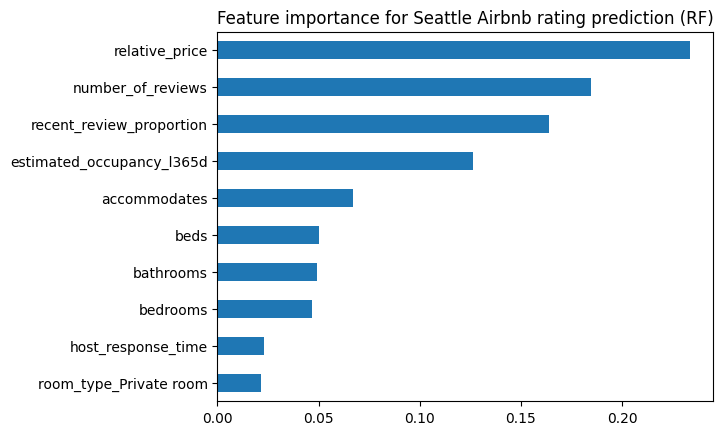

In [304]:
importance.sort_values().tail(10).plot(kind="barh")
plt.title("Feature importance for Seattle Airbnb rating prediction (RF)")
plt.show()

In [305]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.638974358974359
[[238 206]
 [146 385]]
              precision    recall  f1-score   support

           0       0.62      0.54      0.57       444
           1       0.65      0.73      0.69       531

    accuracy                           0.64       975
   macro avg       0.64      0.63      0.63       975
weighted avg       0.64      0.64      0.64       975



## 2. Gradient Boosting

In [306]:
## run GBDT model

X = df_seattle.drop(columns=["review_scores_class"])
y = df_seattle["review_scores_class"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [307]:
for lr in [0.01, 0.05, 0.1, 0.2, 0.5]:
    gb = GradientBoostingClassifier(learning_rate=lr, n_estimators=200, random_state=42)
    gb.fit(X_train, y_train)
    print(f"learning_rate={lr}: {accuracy_score(y_test, gb.predict(X_test)):.4f}")

learning_rate=0.01: 0.6369
learning_rate=0.05: 0.6472
learning_rate=0.1: 0.6503
learning_rate=0.2: 0.6554
learning_rate=0.5: 0.6246


In [308]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.2,
    max_depth=3,
    subsample=1.0,
    random_state=42
)

gb.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.2
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [309]:
importance = pd.Series(
    gb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(15)

relative_price               0.300930
number_of_reviews            0.185650
recent_review_proportion     0.173152
estimated_occupancy_l365d    0.069451
room_type_Private room       0.053251
bathrooms                    0.052438
bedrooms                     0.050949
accommodates                 0.042615
beds                         0.024573
host_response_time           0.021866
is_long_term                 0.015132
host_identity_verified_t     0.007746
room_type_Shared room        0.002247
dtype: float64

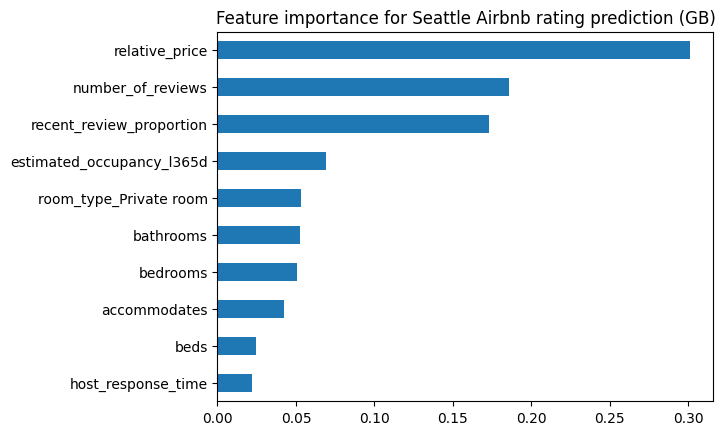

In [310]:
importance.sort_values().tail(10).plot(kind="barh")
plt.title("Feature importance for Seattle Airbnb rating prediction (GB)")
plt.show()

In [311]:
y_pred = gb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6553846153846153
[[228 216]
 [120 411]]
              precision    recall  f1-score   support

           0       0.66      0.51      0.58       444
           1       0.66      0.77      0.71       531

    accuracy                           0.66       975
   macro avg       0.66      0.64      0.64       975
weighted avg       0.66      0.66      0.65       975



## 3. KNN

In [312]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [313]:
for k in range(3, 20, 2):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    print(f"k={k}: {accuracy_score(y_test, knn.predict(X_test_scaled)):.4f}")

k=3: 0.5979
k=5: 0.5979
k=7: 0.6297
k=9: 0.6215
k=11: 0.6205
k=13: 0.6318
k=15: 0.6338
k=17: 0.6297
k=19: 0.6215


In [314]:
knn = KNeighborsClassifier(n_neighbors=13)
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",13
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [315]:
y_pred = knn.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6317948717948718
[[210 234]
 [125 406]]
              precision    recall  f1-score   support

           0       0.63      0.47      0.54       444
           1       0.63      0.76      0.69       531

    accuracy                           0.63       975
   macro avg       0.63      0.62      0.62       975
weighted avg       0.63      0.63      0.62       975



## 4. Logistic Regression

In [317]:
for c in [0.01, 0.1, 1, 10, 100]:
    lr = LogisticRegression(C=c, max_iter=1000, random_state=42)
    lr.fit(X_train_scaled, y_train)
    print(f"C={c}: {accuracy_score(y_test, lr.predict(X_test_scaled)):.4f}")

C=0.01: 0.6318
C=0.1: 0.6503
C=1: 0.6503
C=10: 0.6513
C=100: 0.6513


In [316]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
    
y_pred = lr.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6502564102564102
[[205 239]
 [102 429]]
              precision    recall  f1-score   support

           0       0.67      0.46      0.55       444
           1       0.64      0.81      0.72       531

    accuracy                           0.65       975
   macro avg       0.65      0.63      0.63       975
weighted avg       0.65      0.65      0.64       975

